# Multiple Linear Regression
Multiple Linear Regression (MLR) predicts a continuous outcome using several input factors simultaneously, instead of just one. The model learns how important, or "weighted," each factor is to make an accurate prediction.

## Feature Matrix and Target Vector
In MLR, the original dataset is divided into:
- **Feature Matrix (X)**: A table where each row represents a data point and each column represents a different input factor (feature).
- **Target Vector (y)**: A single column that contains the outcome we want to predict.

### Model Representation
The MLR model can be represented mathematically as:\
ŷ = β + w1X1 + w2X2 + ... + wnXn + ε\
Where:
- ŷ: Predicted outcome
- β: Intercept (constant term) or bias
- w1, w2, ..., wn: Coefficients (weights) for each feature
- X1, X2, ..., Xn: Input features
- ε: Error term (captures randomness or noise)

### Formulate the Model
The model can be represent as ŷ = Xw + β\
Where:
- ŷ: Target vector = [ŷ1, ŷ2, ŷ3, ..., ŷm]^T
- w: Weight vector = [w1, w2, w3, ..., wn]^
- X: Feature matrix =
```| X11  X12  X13  ...  X1n |
| X21  X22  X23  ...  X2n |
| X31  X32  X33  ...  X3n |
| ...  ...  ...  ...  ... |
| Xm1  Xm2  Xm3  ...  Xmn |
```
- β: Intercept (bias) = Vector of ones of size m = [1, 1, 1, ..., 1]^T

## The Hyperplane In MLR
In MLR, the model predicts outcomes by fitting a hyperplane in a multi-dimensional space defined by the input features. Each feature corresponds to a dimension, and the hyperplane represents the best fit that minimizes the difference between predicted and actual outcomes.\
Think of simple prediction as drawing a straight line. With Multiple Linear Regression (MLR) and many factors, we fit a more complex "hyperplane"—a multi-dimensional line—to capture all the relationships in our data.

MLR's goal is to find the perfect "recipe" (combination of weights) for each factor. It constantly adjusts these weights to make its predictions as close as possible to the actual results. Imagine a chef tweaking ingredients until the dish tastes just right.

## Cost Function
To measure how well the model predicts the target values, we use a cost function. A common choice for MLR is the Mean Squared Error (MSE), which calculates the average of the squared differences between the actual and predicted values. The goal is to minimize this cost function during training.\
The cost function J(w, β) can be defined as:

J(w, β) = (1/2m) * Σ(yi - ŷi)²\
or,J(w, β) = (1/2m) * ||y - ŷ||²\
Where:
- J(w, β): Cost function
- m: Number of data points
- yi: Actual target value for the i-th data point
- ŷi: Predicted target value for the i-th data point
- ||y - ŷ||²: Squared norm of the difference between actual and predicted values
- ||...||²: Squared Euclidean norm(Euclidean distance)

## Gradient of Cost Function
To optimize the weights and bias, we compute the gradient of the cost function with respect to the weights and bias. The gradients indicate the direction and rate of change of the cost function, guiding us on how to adjust the weights and bias to minimize the cost.\
The gradients can be calculated as:\

∇wJ(w, β) = -(1/m) * X^T * (y - Xw)\
∇βJ(w, β) = -(1/m) * Σ(yi - ŷi)\
Where:
- ∇wJ(w, β): Gradient of the cost function with respect to weights
- ∇βJ(w, β): Gradient of the cost function with respect to bias
- X^T: Transpose of the feature matrix X
- m: Number of data points
- y: Actual target vector
- ŷ: Predicted target vector
- Xw: Matrix multiplication of feature matrix X and weight vector w

## Gradient Descent Algorithm
The Gradient Descent algorithm iteratively updates the weights and bias to minimize the cost function. In each iteration, the weights and bias are adjusted in the opposite direction of the gradient, scaled by a learning rate (α). This process continues until convergence, where the cost function reaches a minimum value.\
The update rules for weights and bias are as follows:\

w(new) = w(old) - α * ∇wJ[w(old), β(old)]\
β(new) = β(old) - α * ∇βJ[w(old), β(old)]\
Where:
- w(new): Updated weight vector
- w(old): Previous weight vector
- β(new): Updated bias
- β(old): Previous bias
- α: Learning rate (a small positive value that controls the step size), it's a hyperparameter and has a very small value like 0.01, 0.001 etc.
- ∇wJ[w(old), β(old)]: Gradient of the cost function with respect to weights at the previous iteration
- ∇βJ[w(old), β(old)]: Gradient of the cost function with respect to bias at the previous iteration

### Learning Rate
The learning rate (α) is a crucial hyperparameter in the Gradient Descent algorithm. It determines the size of the steps taken towards the minimum of the cost function during each iteration. A well-chosen learning rate can significantly impact the convergence speed and stability of the optimization process.\
Like steering a car, a small turn (low learning rate) means slow progress but more control, while a big turn (high learning rate) can lead to faster results but risks overshooting the target.

In [4]:
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing(as_frame=True)        #'as_frame=True' returns a pandas DataFrame

df = california.frame.copy()
df.head(10)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


In [6]:
target_col ='MedHouseVal'
feature_cols = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']

X = df[feature_cols]
y = df[target_col]

print('Shape of X: ', X.shape)
print('Shape of y: ', y.shape)

Shape of X:  (20640, 6)
Shape of y:  (20640,)


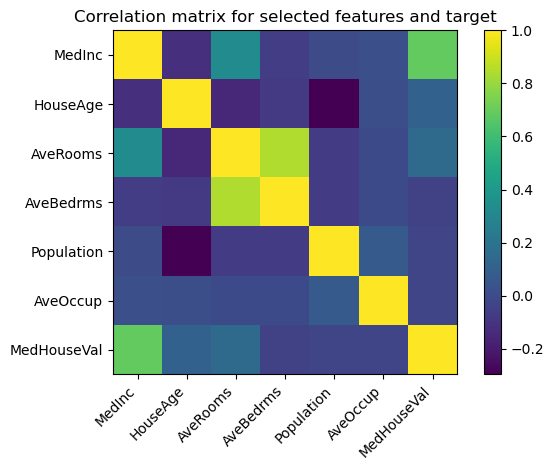

In [7]:
import matplotlib.pyplot as plt

# Correlation between selected features and the target
corr_matrix = df[feature_cols + [target_col]].corr()

fig, ax = plt.subplots()
cax = ax.imshow(corr_matrix.values, interpolation='nearest')
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_matrix.index)
fig.colorbar(cax)
ax.set_title('Correlation matrix for selected features and target')
plt.tight_layout()
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

LinearRegression()

In [10]:
print('Intercept (bias term): ', lin_reg.intercept_)
print('\nCoefficients: ')
for feature_name, coef in zip(feature_cols, lin_reg.coef_):
  print(f'{feature_name}: {coef}')

Intercept (bias term):  -0.5528727644615179

Coefficients: 
MedInc: 0.5461607791074247
HouseAge: 0.016787909062566837
AveRooms: -0.22391994400480003
AveBedrms: 1.1154926114808403
Population: 2.3167197368236063e-05
AveOccup: -0.0046182313454072805


In [12]:
y_train_pred = lin_reg.predict(X_train)
y_test_pred = lin_reg.predict(X_test)

print('Some sample predicitons on test set (first 5 rows): ')
print('Predicted: ', y_test_pred[:5])
print('Actual: ', y_test.values[:5])

Some sample predicitons on test set (first 5 rows): 
Predicted:  [1.00100537 1.56005635 2.67713262 2.64763331 1.98229968]
Actual:  [0.477   0.458   5.00001 2.186   2.78   ]


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def regression_metrics(y_true, y_pred, label='Model'):
  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_true, y_pred)

  print(f'=== {label} ====')
  print('MAE: ', mae)
  print('RMSE: ', rmse)
  print('R2 : ', r2)
  print()

regression_metrics(y_train, y_train_pred, label='Linear Regression (Train)')
regression_metrics(y_test, y_test_pred, label='Linear Regression (Test)')

=== Linear Regression (Train) ====
MAE:  0.5708698051066725
RMSE:  0.7791080690513484
R2 :  0.5459161602818385

=== Linear Regression (Test) ====
MAE:  0.5792140665454437
RMSE:  0.8013658536857469
R2 :  0.5099337366296425



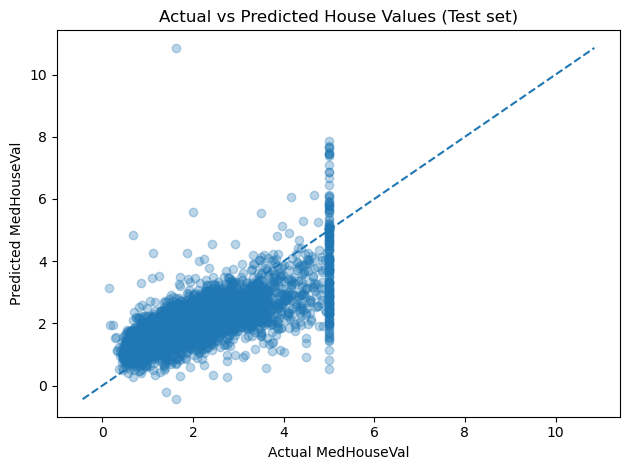

In [15]:
plt.figure()
plt.scatter(y_test, y_test_pred, alpha=0.3)
plt.xlabel('Actual MedHouseVal')
plt.ylabel('Predicted MedHouseVal')
plt.title('Actual vs Predicted House Values (Test set)')

# Diagonal reference line
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')
plt.tight_layout()
plt.show()

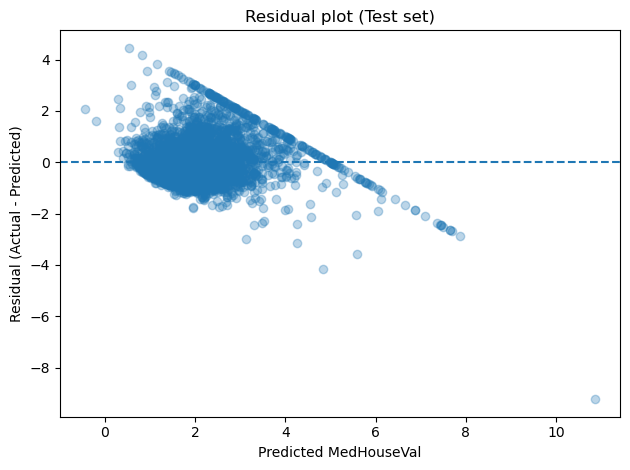

In [16]:
residuals = y_test - y_test_pred

plt.figure()
plt.scatter(y_test_pred, residuals, alpha=0.3)
plt.axhline(0, linestyle='--')
plt.xlabel('Predicted MedHouseVal')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual plot (Test set)')
plt.tight_layout()
plt.show()

# Polynomial Regression
Polynomial Regression is an extension of linear regression that models the relationship between the independent variable (X) and the dependent variable (y) as an nth degree polynomial. This allows the model to capture non-linear relationships in the data.\
The polynomial regression model can be represented mathematically as:\
ŷ = β + w1X + w2X² + w3X³ + ... + wnX^d + ε
Where:
- ŷ: Predicted outcome
- β: Intercept (constant term) or bias
- w1, w2, ..., wn: Coefficients (weights) for each polynomial term
- X, X², X³, ..., X^d: Input features raised to the power of 1 to d
- ε: Error term (captures randomness or noise)

### Formulate the Model
Let, single feature of degree d, the polynomial matrix can be represented as: φd(x) =
```
   | X1 |
   | X1²|
   | X1³|
   | ...|
   | X1^d|
```
and w as weight vector = [w1, w2, w3, ..., wd]^T\
Then the model can be represented as: ŷ = φd(x)w + β

If there are multiple feartures, the total number of terms in the φd(x) will be C(d+p, d) or (p+d)C(d) where p is the number of features and d is the degree of polynomial. If excluding the bias term then the total number of terms will be C(d+p, d) - 1 or (p+d)C(d) - 1.

##### Example:
3 features and polynomial degree 2\
Total number of terms = C(2+3, 2) = 5C2 = 10\
The polynomial matrix φ2(x) will be:
```
   | X   |
   | Y   |
   | Z   |
   | X²  |
   | Y²  |
   | Z²  |
   | XY   |
   | XZ   |
   | YZ   |
   | 1    |
```
And weight vector w will be: [w1, w2, w3, w4, w5, w6, w7, w8, w9, β]^T
So, the model can be represented as: ŷ = φ2(x)w = w1X + w2Y + w3Z + w4X² + w5Y² + w6Z² + w7XY + w8XZ + w9YZ + β

### Polynomial Regression as Linear Regression in Feature Space
Polynomial Regression can be viewed as a special case of Linear Regression when we transform the original input features into a higher-dimensional feature space using polynomial basis functions. In this transformed space, the relationship between the input features and the target variable can be modeled linearly, even though the original relationship may be non-linear.\
φ=[φd(x)^T\
    φd(x²)^T\
    φd(x³)^T\
    ...\
    φd(x^n)^T]
Where, φd(x^i) is the polynomial feature matrix for the i-th original feature x^i, and T denotes the transpose operation.\
Then the model can be represented as:\

ŷ = φw + β

What does this mean?\
By transforming the input features into polynomial terms, we can apply linear regression techniques to capture complex, non-linear relationships in the data. This approach allows us to leverage the simplicity and interpretability of linear models while accommodating more intricate patterns through polynomial transformations.

### What Problems Does Polynomial Regression Solve?
Linear regression assumes a straight-line relationship between variables, but real-world data often follows curved patterns. When data bends and curves, a straight line simply won't capture the true relationship.
Polynomial regression extends linear models to handle these curved relationships while maintaining mathematical simplicity and interpretability.

### The Risk of Polynomial Regression
1. **Overfitting**: High-degree polynomials can fit the training data too closely, capturing noise instead of the underlying trend. This leads to poor generalization on new data.
2. **Underfitting**: Conversely, using a polynomial degree that is too low may fail to capture the complexity of the data, resulting in a model that does not fit well.
3. **Complexity**: As the degree of the polynomial increases, the model becomes more complex, making it harder to interpret and understand the relationships between variables.

## Training Error vs Polynomial Degree
As the polynomial degree increases, the training error typically decreases because the model becomes more flexible and can fit the training data more closely. However, this can lead to overfitting, where the model captures noise in the training data rather than the underlying pattern. It's important to find a balance between model complexity and generalization to new data.
Let, J[train(d)] be the minimum training error for polynomial degree d.\
Then, J[train(1)] ≥ J[train(2)] >= J[train(3)] ≥ ... ≥ J[train(d)] 

## Test Error and Bias-Variance Tradeoff: Approximate Decomposition
As the polynomial degree increases, the test error may initially decrease as the model captures more complex patterns in the data. However, beyond a certain point, the test error may start to increase due to overfitting, where the model learns noise in the training data instead of the underlying trend. This phenomenon illustrates the bias-variance tradeoff, where increasing model complexity reduces bias but increases variance, leading to higher test error. The goal is to find an optimal polynomial degree that balances bias and variance for the best generalization to new data.\
Why it is called Approximate Decomposition? Because the exact decomposition of test error into bias and variance components is often complex and depends on the specific data distribution and model assumptions. However, the approximate decomposition provides a useful framework for understanding how different sources of error contribute to the overall test error.\
The approximate decomposition of test error can be expressed as:\
Error ~ [Bias(d)]² + Variance(d) + Irreducible Error\
Where:
- Bias(d): Error due to overly simplistic assumptions in the model at degree d
- Variance(d): Error due to excessive sensitivity to small fluctuations in the training data at degree d
- Irreducible Error/Noise: Error inherent in the data that cannot be reduced by any model

As degree d increases, Bias(d) decreases and Variance(d) increases.\
So optimal degree d is the one that minimizes the total error.
- Degree 1: Linear model - maximum bias, minimum variance
- Degree 2-3: Sweet spot for many real-world problems
- Degree 4-5+: High flexibility but risk of overfitting increases
- Degree 10+: Extreme variance - rarely generalizes well

In [20]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
import pandas as pd

degrees = [1,2,3,5]
results = []

for deg in degrees:
  model = Pipeline([
      ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
      ('lin_reg', LinearRegression())
  ])
  # PolynomialFeatures() will create polynomial and interaction features up to the specified degree.
  # LinearRegression() will fit a linear model to these transformed features. This will help to get the coefficients.

  model.fit(X_train, y_train)

  y_train_pred_deg = model.predict(X_train)
  y_test_pred_deg = model.predict(X_test)

  mae_train = mean_absolute_error(y_train, y_train_pred_deg)
  rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred_deg))
  r2_train = r2_score(y_train, y_train_pred_deg)

  mae_test = mean_absolute_error(y_test, y_test_pred_deg)
  rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred_deg))
  r2_test = r2_score(y_test, y_test_pred_deg)

  results.append({
      'degree': deg,
      'MAE_train': mae_train,
      'RMSE_train': rmse_train,
      'R2_train': r2_train,
      'MAE_test': mae_test,
      'RMSE_test': rmse_test,
      'R2_test': r2_test,
  })

results_df = pd.DataFrame(results)
results_df

,degree,MAE_train,RMSE_train,R2_train,MAE_test,RMSE_test,R2_test
0,1,0.570870,0.779108,0.545916,0.579214,0.801366,0.509934
1,2,0.533330,0.727319,0.604277,0.538320,0.747030,0.574137
2,3,0.489501,0.673149,0.661028,0.559639,2.668373,-4.433582
3,5,0.799412,1.040542,0.190046,0.916070,7.739418,-44.709849


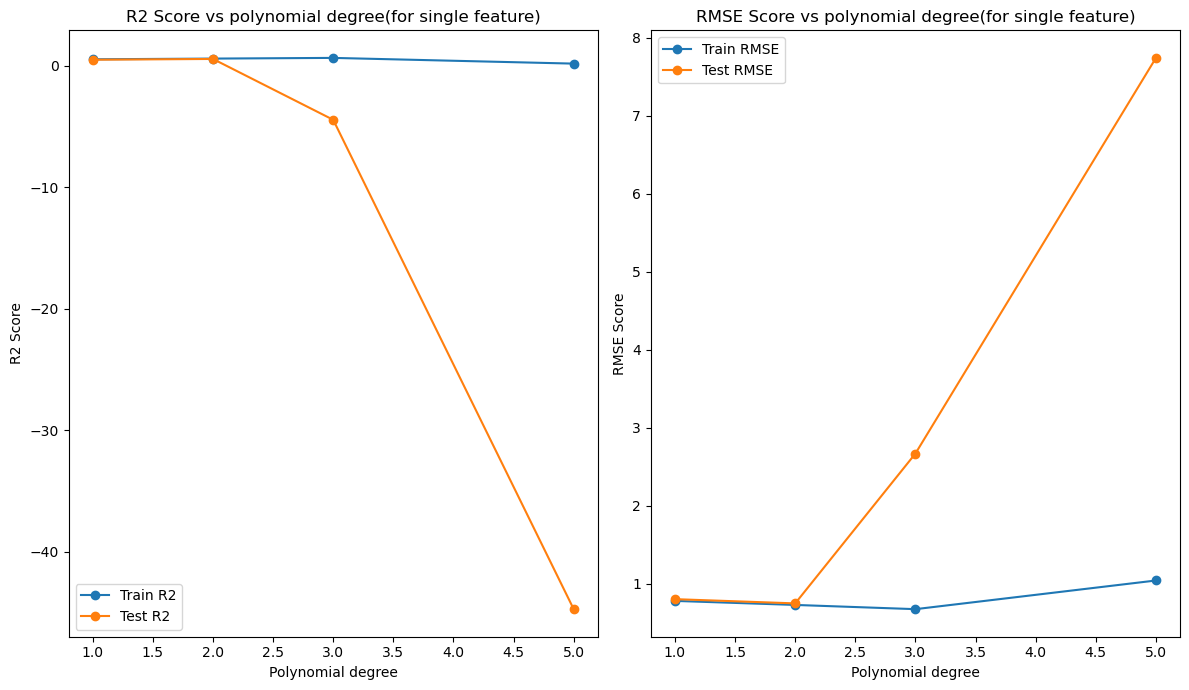

In [21]:
fig, axes = plt.subplots(1,2, figsize=(12,7))


# R squared plot
axes[0].plot(results_df['degree'], results_df['R2_train'],marker='o',label='Train R2')
axes[0].plot(results_df['degree'], results_df['R2_test'],marker='o',label='Test R2')
axes[0].set_xlabel("Polynomial degree")
axes[0].set_ylabel("R2 Score")
axes[0].set_title("R2 Score vs polynomial degree(for single feature)")
axes[0].legend()

# RMSE plot
axes[1].plot(results_df['degree'], results_df['RMSE_train'],marker='o',label='Train RMSE')
axes[1].plot(results_df['degree'], results_df['RMSE_test'],marker='o',label='Test RMSE')
axes[1].set_xlabel("Polynomial degree")
axes[1].set_ylabel("RMSE Score")
axes[1].set_title("RMSE Score vs polynomial degree(for single feature)")
axes[1].legend()

plt.tight_layout()
plt.show()
